# Регрессия 

Лаборатная работа 2. Предсказание продолжительности поездки в такси на основе алгоритмов регрессии.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import optuna
from sklearn.utils import parallel_backend

d:\Programming\ML-labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Считваем предобработанные данные

In [2]:
data = pd.read_csv('../data/processed_trip_duration.csv')
data.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,in_nyc_center?,distance,hour_1,hour_2,...,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24,is_it_weekday?,is_it_first_vendor?(else 2nd)
0,1,-73.953918,40.778873,-73.963875,40.771164,400,1,1199.769914,1,0,...,0,0,0,0,0,0,0,0,1,0
1,2,-73.988312,40.731743,-73.994751,40.694931,1100,1,4123.945168,0,1,...,0,0,0,0,0,0,0,0,1,1
2,2,-73.997314,40.721458,-73.948029,40.774918,1635,1,7250.435807,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,-73.961670,40.759720,-73.956779,40.780628,1141,1,2358.286547,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2,-73.993614,40.751884,-73.995422,40.723862,1455,1,3115.641570,0,0,...,0,0,0,0,0,0,0,0,0,0


# Простая линейная регрессия

## Выделяем целевой признак и предиктор ()

In [4]:
y = data['trip_duration']
X = data[['distance']]

In [5]:
y

0          400
1         1100
2         1635
3         1141
4         1455
          ... 
655752     296
655753     315
655754     673
655755     447
655756    1224
Name: trip_duration, Length: 655757, dtype: int64

In [6]:
X

,distance
0,1199.769914
1,4123.945168
2,7250.435807
3,2358.286547
4,3115.641570
...,...
655752,1123.068070
655753,728.563489
655754,2295.919143
655755,846.721940


## Разделение данных на тренировочные и тестовые

In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Масштабирование данных

In [8]:
scaler = StandardScaler()

In [9]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Обучение модели регрессии

In [10]:
lr = LinearRegression().fit(X_train, y_train)

In [11]:
y_pred = lr.predict(X_test)

### Метрики качества

In [12]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 247.82888405683244
MSE: 111765.06203817712
RMSE: 334.31282063088327
MAPE: 0.6865914713906066
R^2: 0.516142074204641


### Визуализация результатов

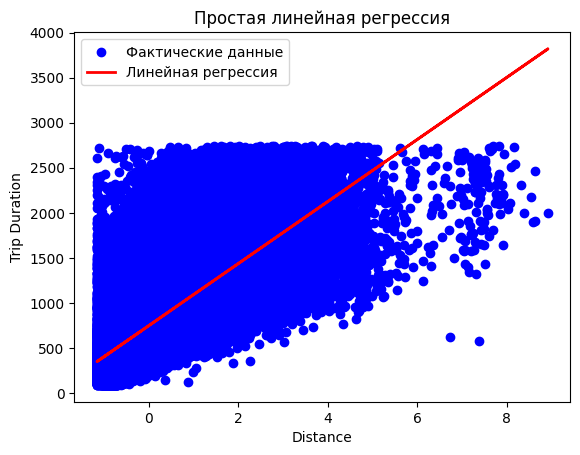

In [13]:
plt.scatter(X_test, y_test, color="blue", label="Фактические данные")  # Точки реальных данных
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Линейная регрессия")  # Линия предсказаний
plt.xlabel("Distance")
plt.ylabel("Trip Duration")
plt.title("Простая линейная регрессия")
plt.legend()
plt.show()

# Регрессия с регуляризацией

In [3]:
X = data.drop(['trip_duration'], axis=1)
y = data['trip_duration']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((524605, 33), (524605,), (131152, 33), (131152,))

## Lasso (L1)

Использование регуляризации Lasso с заданными параметрами

In [17]:
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)

In [18]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {lasso.score(X_test, y_test)}')
lasso.coef_

MAE: 229.60089741312606
MSE: 98517.84402779867
RMSE: 313.87552314221426
MAPE: 0.6549967800781312
R^2: 0.5705287907836902


array([ 2.64766549e+00, -7.47277667e+02, -0.00000000e+00, -9.60638716e+00,
       -7.62733677e+02,  9.00095355e+01,  1.53914154e-01,  8.45997524e+01,
       -6.30379757e+01,  8.54463723e+01,  7.22665980e+01,  7.13809018e+01,
       -3.60021232e+01,  7.83721286e+00, -4.58713392e+01,  9.45219679e+01,
        3.98389690e+01, -5.19446361e+01, -1.40364104e+02,  1.03000854e+02,
       -6.57157784e+01,  1.05576976e+02,  9.44342594e+01,  1.01925630e+02,
        7.36507504e+01, -7.44584357e+01, -2.19463079e+02, -1.26012033e+02,
       -1.75850025e+02, -2.46797825e+02, -1.08167539e+02,  8.16459874e+01,
        0.00000000e+00])

### Подбор параметров для модели Lasso

In [36]:
parameters = {'alpha': np.arange(0.1, 1.1, 0.1)}
parameters

{'alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

Перебор параметров с помощью GridSearch

In [37]:
lasso_optimal1 = GridSearchCV(Lasso(), parameters).fit(X_train, y_train)
lasso_optimal1.best_params_

{'alpha': np.float64(0.1)}

In [38]:
y_pred = lasso_optimal1.predict(X_test)

In [39]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {lasso.score(X_test, y_test)}')
lasso.coef_

MAE: 227.9997874153859
MSE: 97202.41486099482
RMSE: 311.77301817346995
MAPE: 0.6507925718211044
R^2: 0.5705287907836902


array([ 2.64766549e+00, -7.47277667e+02, -0.00000000e+00, -9.60638716e+00,
       -7.62733677e+02,  9.00095355e+01,  1.53914154e-01,  8.45997524e+01,
       -6.30379757e+01,  8.54463723e+01,  7.22665980e+01,  7.13809018e+01,
       -3.60021232e+01,  7.83721286e+00, -4.58713392e+01,  9.45219679e+01,
        3.98389690e+01, -5.19446361e+01, -1.40364104e+02,  1.03000854e+02,
       -6.57157784e+01,  1.05576976e+02,  9.44342594e+01,  1.01925630e+02,
        7.36507504e+01, -7.44584357e+01, -2.19463079e+02, -1.26012033e+02,
       -1.75850025e+02, -2.46797825e+02, -1.08167539e+02,  8.16459874e+01,
        0.00000000e+00])

Перебор параметров с помощью RandomizedSearch

In [40]:
parameters = {'alpha': np.arange(0.1, 1.1, 0.01)}
parameters

{'alpha': array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
        0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
        0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
        0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
        0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
        0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75,
        0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86,
        0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97,
        0.98, 0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08,
        1.09])}

In [41]:
lasso_optimal2 = RandomizedSearchCV(Lasso(), parameters).fit(X_train, y_train)
lasso_optimal2.best_params_

{'alpha': np.float64(0.13)}

In [42]:
y_pred = lasso_optimal2.predict(X_test)

In [43]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {lasso.score(X_test, y_test)}')
lasso.coef_

MAE: 228.07983034433403
MSE: 97290.53813501594
RMSE: 311.91431216764636
MAPE: 0.6510559883228372
R^2: 0.5705287907836902


array([ 2.64766549e+00, -7.47277667e+02, -0.00000000e+00, -9.60638716e+00,
       -7.62733677e+02,  9.00095355e+01,  1.53914154e-01,  8.45997524e+01,
       -6.30379757e+01,  8.54463723e+01,  7.22665980e+01,  7.13809018e+01,
       -3.60021232e+01,  7.83721286e+00, -4.58713392e+01,  9.45219679e+01,
        3.98389690e+01, -5.19446361e+01, -1.40364104e+02,  1.03000854e+02,
       -6.57157784e+01,  1.05576976e+02,  9.44342594e+01,  1.01925630e+02,
        7.36507504e+01, -7.44584357e+01, -2.19463079e+02, -1.26012033e+02,
       -1.75850025e+02, -2.46797825e+02, -1.08167539e+02,  8.16459874e+01,
        0.00000000e+00])

Подбор параметров с помощью Optuta

In [ ]:
# Функция для оптимизации гиперпараметров
def objective_lasso(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-5, 1e2)
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    return mse

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective_lasso, n_trials=100)

best_params = study.best_params
best_model = Lasso(alpha=best_params['alpha'])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [62]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Лучшие гиперпараметры: alpha = {best_params['alpha']}")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")

Лучшие гиперпараметры: alpha = 0.020315758655410805
R²: 0.5767
MSE: 97103.7283


## Ridge (L2)

In [ ]:
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

In [45]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {lasso.score(X_test, y_test)}')
ridge.coef_

MAE: 227.9525716093375
MSE: 97109.16905095075
RMSE: 311.6234411127487
MAPE: 0.6502028751198411
R^2: 0.5705287907836902


array([ 3.01831798e+00, -2.16439161e+03,  1.28911440e+03, -6.97023013e+02,
       -1.50613683e+03, -2.97047693e+00,  1.62239728e-01,  1.23734961e+02,
       -5.25305414e+01,  1.21361888e+02,  1.06766386e+02,  1.03644403e+02,
       -2.24231558e+01,  3.88473989e+01, -3.44096694e+01,  1.30517381e+02,
        7.49697586e+01, -3.94439369e+01, -1.56122751e+02,  1.40626321e+02,
       -5.23807205e+01,  1.42088335e+02,  1.30575435e+02,  1.37631096e+02,
        1.09546252e+02, -6.85306358e+01, -2.17205369e+02, -1.32806817e+02,
       -2.02635692e+02, -2.74435796e+02, -1.07384529e+02,  8.37387216e+01,
        9.00240868e-01])

### Подбор параметров для модели Ridge

Перебор параметров с помощью GridSearchCV

In [50]:
parameters = {'alpha': np.arange(0.1, 1.1, 0.1)}
parameters

{'alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

In [51]:
ridge_optimal1 = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal1.best_params_

{'alpha': np.float64(0.1)}

In [52]:
y_pred = ridge_optimal1.predict(X_test)

In [53]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {ridge.score(X_test, y_test)}')
ridge.coef_

MAE: 227.9531986895558
MSE: 97109.86648397107
RMSE: 311.624560142443
MAPE: 0.6501952126772759
R^2: 0.5766696615230957


array([ 3.01831798e+00, -2.16439161e+03,  1.28911440e+03, -6.97023013e+02,
       -1.50613683e+03, -2.97047693e+00,  1.62239728e-01,  1.23734961e+02,
       -5.25305414e+01,  1.21361888e+02,  1.06766386e+02,  1.03644403e+02,
       -2.24231558e+01,  3.88473989e+01, -3.44096694e+01,  1.30517381e+02,
        7.49697586e+01, -3.94439369e+01, -1.56122751e+02,  1.40626321e+02,
       -5.23807205e+01,  1.42088335e+02,  1.30575435e+02,  1.37631096e+02,
        1.09546252e+02, -6.85306358e+01, -2.17205369e+02, -1.32806817e+02,
       -2.02635692e+02, -2.74435796e+02, -1.07384529e+02,  8.37387216e+01,
        9.00240868e-01])

Перебор параметров с помощью RandomizedSearchCV

In [54]:
parameters = {'alpha': np.arange(0.1, 1.1, 0.01)}
parameters

{'alpha': array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
        0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
        0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
        0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
        0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
        0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75,
        0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86,
        0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97,
        0.98, 0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08,
        1.09])}

In [55]:
ridge_optimal2 = RandomizedSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal2.best_params_

{'alpha': np.float64(0.2599999999999999)}

In [56]:
y_pred = ridge_optimal2.predict(X_test)

In [77]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {ridge.score(X_test, y_test)}')
ridge.coef_

MAE: 227.9997874153859
MSE: 97202.41486099482
RMSE: 311.77301817346995
MAPE: 0.6507925718211044
R^2: 0.5766696615230957


array([ 3.01831798e+00, -2.16439161e+03,  1.28911440e+03, -6.97023013e+02,
       -1.50613683e+03, -2.97047693e+00,  1.62239728e-01,  1.23734961e+02,
       -5.25305414e+01,  1.21361888e+02,  1.06766386e+02,  1.03644403e+02,
       -2.24231558e+01,  3.88473989e+01, -3.44096694e+01,  1.30517381e+02,
        7.49697586e+01, -3.94439369e+01, -1.56122751e+02,  1.40626321e+02,
       -5.23807205e+01,  1.42088335e+02,  1.30575435e+02,  1.37631096e+02,
        1.09546252e+02, -6.85306358e+01, -2.17205369e+02, -1.32806817e+02,
       -2.02635692e+02, -2.74435796e+02, -1.07384529e+02,  8.37387216e+01,
        9.00240868e-01])

Подбор параметров с помощью Optuna

In [ ]:
def objective_ridge(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-5, 1e2)
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    return mse

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective_ridge, n_trials=100)

best_params = study.best_params
best_model = Ridge(alpha=best_params['alpha'])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [66]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Лучшие гиперпараметры: alpha = {best_params['alpha']}")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")

Лучшие гиперпараметры: alpha = 7.114290809697964
R²: 0.5767
MSE: 97103.9530


## Elastic Net

Перебор параметров через GridSearch

In [98]:
base_elastic_model = ElasticNet(max_iter=100000)

In [99]:
param_grid = {'alpha':[0.1,1,10,100],'l1_ratio':[0.1,0.75,0.99,1]}

In [100]:
grid_model = GridSearchCV(base_elastic_model,
                          param_grid=param_grid,
                         scoring = 'neg_mean_squared_error',
                         cv = 5, verbose = 2)

In [101]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.3s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.3s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.3s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.3s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.3s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.4s
[CV] END ...........................alpha=0.1, l1_ratio=0.99; total time=   2.7s
[CV] END ...........................alpha=0.1, l

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=100000),
             param_grid={'alpha': [0.1, 1, 10, 100],
                         'l1_ratio': [0.1, 0.75, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [102]:
y_pred = grid_model.predict(X_test)

In [103]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {round(r2_score(y_test, y_pred),2)}')

MAE: 227.9997874153859
MSE: 97202.41486099482
RMSE: 311.77301817346995
MAPE: 0.6507925718211044
R^2: 0.58


Перебор параметров через Randomized Search

In [104]:
param_distributions = {
    'alpha': np.logspace(-3, 0, 20),   
    'l1_ratio': np.linspace(0, 1, 10) 
}

In [105]:
random_search_model = RandomizedSearchCV(
    estimator=ElasticNet(max_iter=500),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,  
    scoring='r2',
    random_state=42
)

In [106]:
random_search_model.fit(X_train, y_train)

d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.772e+10, tolerance: 8.098e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.781e+10, tolerance: 8.120e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklea

RandomizedSearchCV(cv=3, estimator=ElasticNet(max_iter=500), n_iter=20,
                   param_distributions={'alpha': array([0.001     , 0.00143845, 0.00206914, 0.00297635, 0.00428133,
       0.00615848, 0.00885867, 0.01274275, 0.01832981, 0.02636651,
       0.0379269 , 0.05455595, 0.078476  , 0.11288379, 0.16237767,
       0.23357215, 0.33598183, 0.48329302, 0.6951928 , 1.        ]),
                                        'l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])},
                   random_state=42, scoring='r2')

In [107]:
random_search_model.best_params_

{'l1_ratio': np.float64(1.0), 'alpha': np.float64(0.008858667904100823)}

In [108]:
y_pred = random_search_model.predict(X_test)

In [109]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {round(r2_score(y_test, y_pred),2)}')

MAE: 227.94503548735133
MSE: 97105.68278179904
RMSE: 311.61784734157806
MAPE: 0.65023329383786
R^2: 0.58


Подбор параметров через Optuna

In [6]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 1.0)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=500, warm_start=True, random_state=42)
    
    with parallel_backend('loky'):
        score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    
    return score


In [7]:
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study.optimize(objective, n_trials=30, n_jobs=-1)
print('best params', study.best_params)
print('best MSE', study.best_value)

[I 2025-03-19 17:58:36,800] A new study created in memory with name: no-name-403fea98-4463-4d6b-a7dd-c58941acff6f
C:\Users\Николай\AppData\Local\Temp\ipykernel_16248\3254257557.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 100)
d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class parallel_backend is deprecated; deprecated in 1.5 to be removed in 1.7. Use joblib.{} instead.
  warnings.warn(msg, category=FutureWarning)
[I 2025-03-19 17:59:21,280] Trial 2 finished with value: -111815.37929773425 and parameters: {'alpha': 3.5547792159515015, 'l1_ratio': 0.5199833071794376}. Best is trial 2 with value: -111815.37929773425.
[I 2025-03-19 17:59:22,951] Trial 5 finished with value: -109684.04240832862 and parameters: {'alpha': 0.656082

best params {'alpha': 0.0010630055933112665, 'l1_ratio': 0.9862964963536829}
best MSE -97255.3981807896


In [8]:
best_params = study.best_params
best_model = ElasticNet(**best_params, max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.476e+09, tolerance: 1.214e+07
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.0010630055933112665, l1_ratio=0.9862964963536829,
           random_state=42)

In [9]:
y_pred = best_model.predict(X_test)

In [12]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {round(r2_score(y_test, y_pred),2)}')

MAE: 229.34276097661822
MSE: 98629.5026522542
RMSE: 314.0533436412582
MAPE: 0.6511369948911533
R^2: 0.57


## Полиномиальная регрессия

### Реализация пайплайна

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler